## Random Forest

In [1]:
# Importing packages
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

In [2]:
#grab all the data needed
X_train = pd.read_csv("../data/X_train_data.csv")
y_train = pd.read_csv("../data/Y_train_data.csv")

In [3]:
#further split the data to obtain a new training and testing set
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [4]:
#create a pipeline
pipeline_regressor = Pipeline([
    ('regressor', RandomForestRegressor(random_state=42))
])

In [5]:
#create a parameter table
parameter_grid_regressor = {"regressor__n_estimators": [5, 20, 100], "regressor__max_depth": [2, 5, 10], "regressor__max_features": ['sqrt', 'log2']}
#find best parameter
grid_search_ridge = GridSearchCV(pipeline_regressor, parameter_grid_regressor)
grid_search_ridge.fit(X_train_rf, y_train_rf.values.ravel())
print(grid_search_ridge.best_params_)


{'regressor__max_depth': 10, 'regressor__max_features': 'sqrt', 'regressor__n_estimators': 100}


In [6]:
#grab all the optimal parameters
best_estimators = grid_search_ridge.best_params_["regressor__n_estimators"]
best_depth = grid_search_ridge.best_params_["regressor__max_depth"]
best_features = grid_search_ridge.best_params_["regressor__max_features"]

In [7]:
#create a new pipeline that includes the optimized parameters
pipeline_regressor_improved = Pipeline([
    ('regressor', RandomForestRegressor(n_estimators=best_estimators, max_depth=best_depth, max_features=best_features, random_state=42))
])

In [8]:
#fit the pipeline again with the optimized parameters
pip_improved = pipeline_regressor_improved.fit(X_train_rf, y_train_rf.values.ravel())

In [9]:
#make predictions
y_pred = pipeline_regressor_improved.predict(X_test_rf)

In [ ]:
#score
r2 = r2_score(y_test_rf, y_pred) # Predict on the test set
print("R2 is equal to:", r2)
#score
MSE = mean_squared_error(y_test_rf, y_pred)
print("MSE is equal to: ", MSE)

R2 is equal to: 0.7043830302776891
MSE is eqaul to:  0.2374004410618024


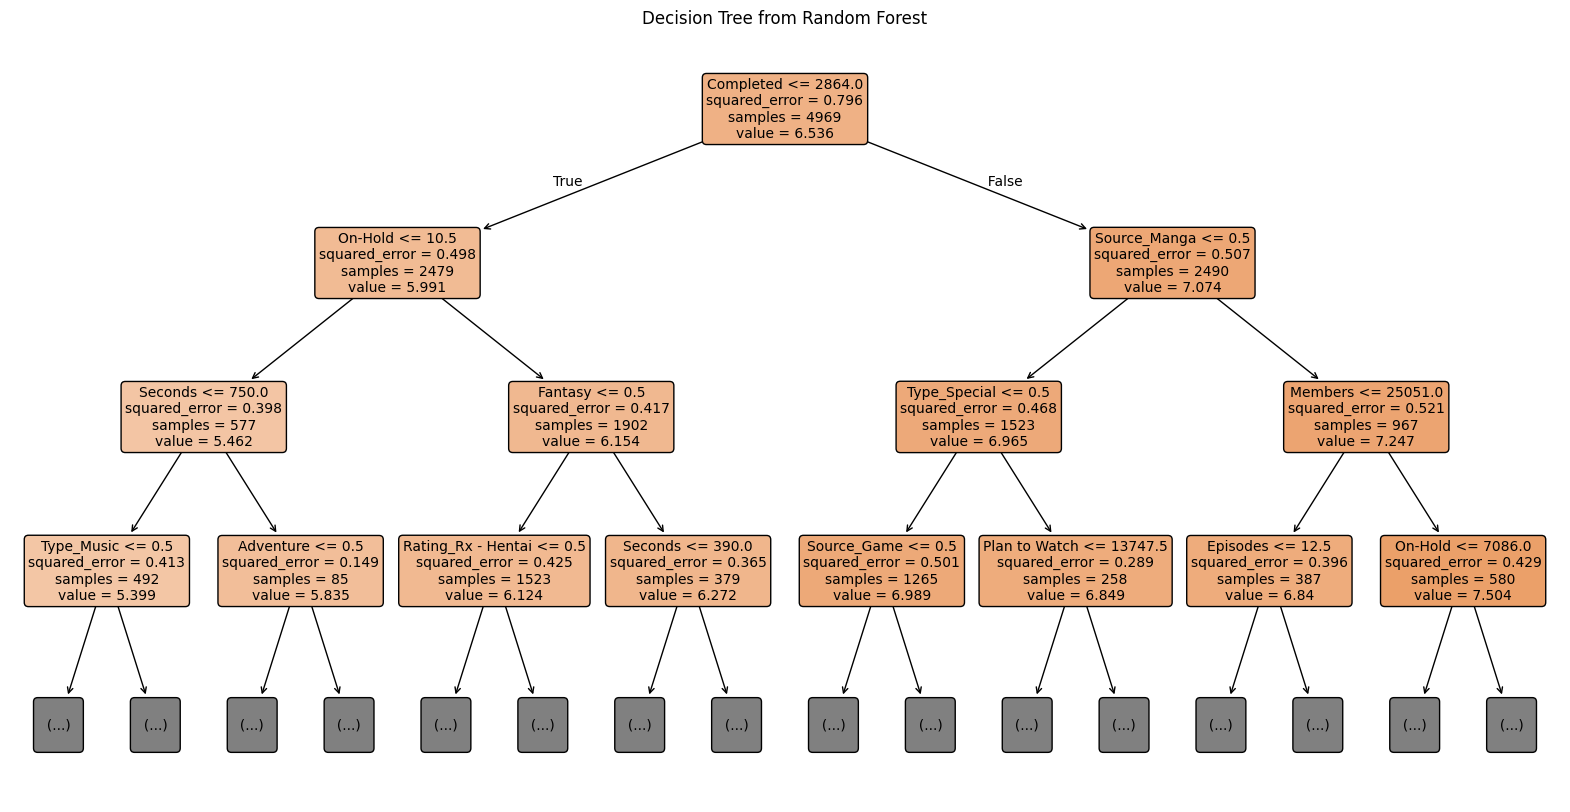

In [13]:
#visualize one of the trees
rf = pipeline_regressor_improved.named_steps["regressor"]
tree_plot = rf.estimators_[0]
cols = X_train.columns

plt.figure(figsize=(20, 10))
plot_tree(tree_plot, feature_names=cols, filled=True, rounded=True, fontsize=10, max_depth = 3)
plt.title("Decision Tree from Random Forest")
plt.savefig("../outputs/tree.png")
plt.show()